In [ ]:
import pandas as pd

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# Q1. Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 367, Columns: 13


In [ ]:
import pandas as pd

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# Q3. Missing value counts and percentages for each variable
for col in df.columns:
    null_count = df[col].isnull().sum()
    pct = round(null_count / len(df) * 100, 2)
    print(f"{col}: {null_count} missing ({pct}%)")

# Q4. Check for duplicated DATE values
print("\nDuplicate dates:", df['DATE'].duplicated().sum())

STATION: 0 missing (0.0%)
DATE: 0 missing (0.0%)
PRCP: 0 missing (0.0%)
SNOW: 1 missing (0.27%)
SNWD: 19 missing (5.18%)
TAVG: 95 missing (25.89%)
TMAX: 0 missing (0.0%)
TMIN: 0 missing (0.0%)
AWND: 96 missing (26.16%)
WDF2: 96 missing (26.16%)
WDF5: 96 missing (26.16%)
WSF2: 96 missing (26.16%)
WSF5: 96 missing (26.16%)

Duplicate dates: 0


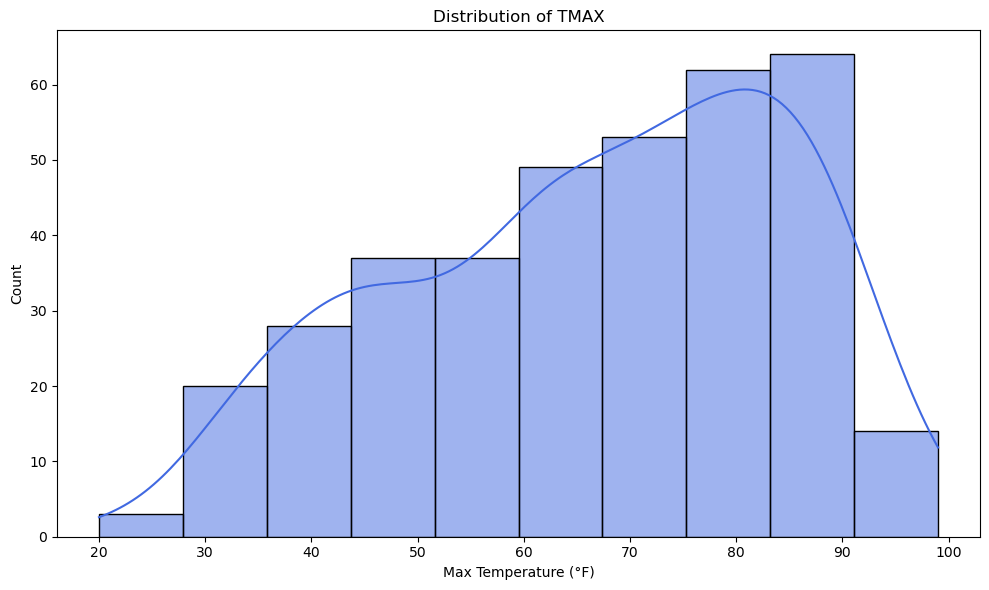

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# F1. Histogram with KDE for TMAX
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df["TMAX"], kde = True, color = "royalblue")
plt.title("Distribution of TMAX")
plt.xlabel("Max Temperature (°F)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

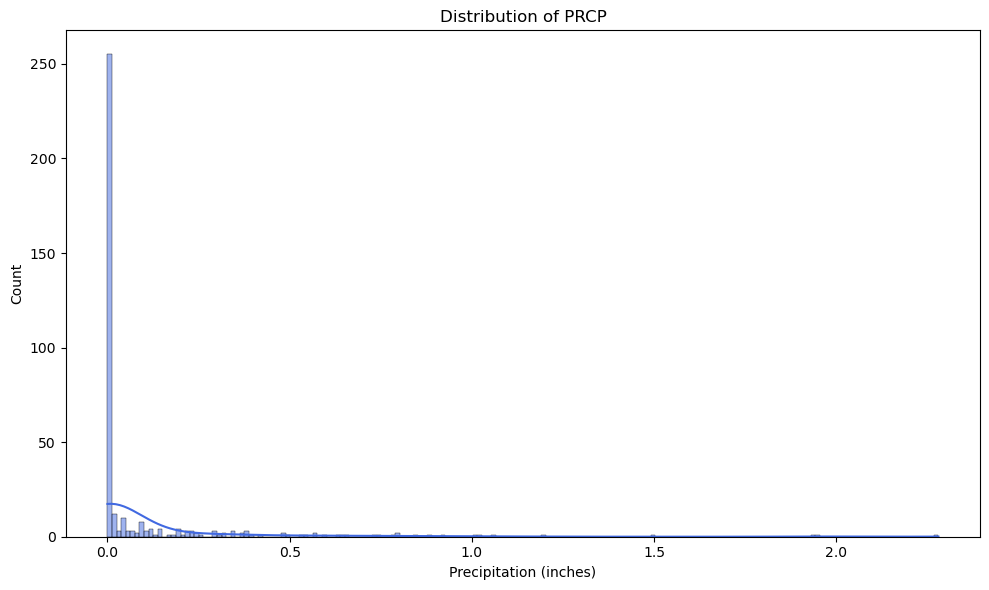

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# F2. Histogram with KDE for PRCP
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df["PRCP"], kde = True, color = "royalblue")
plt.title("Distribution of PRCP")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

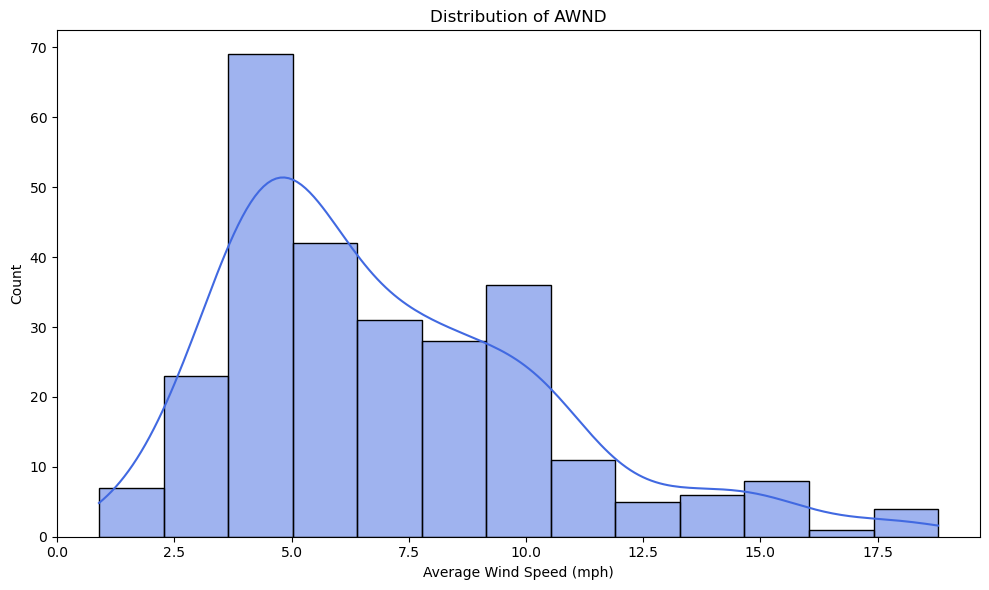

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# F3. Histogram with KDE for AWND
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df["AWND"].dropna(), kde = True, color = "royalblue")
plt.title("Distribution of AWND")
plt.xlabel("Average Wind Speed (mph)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

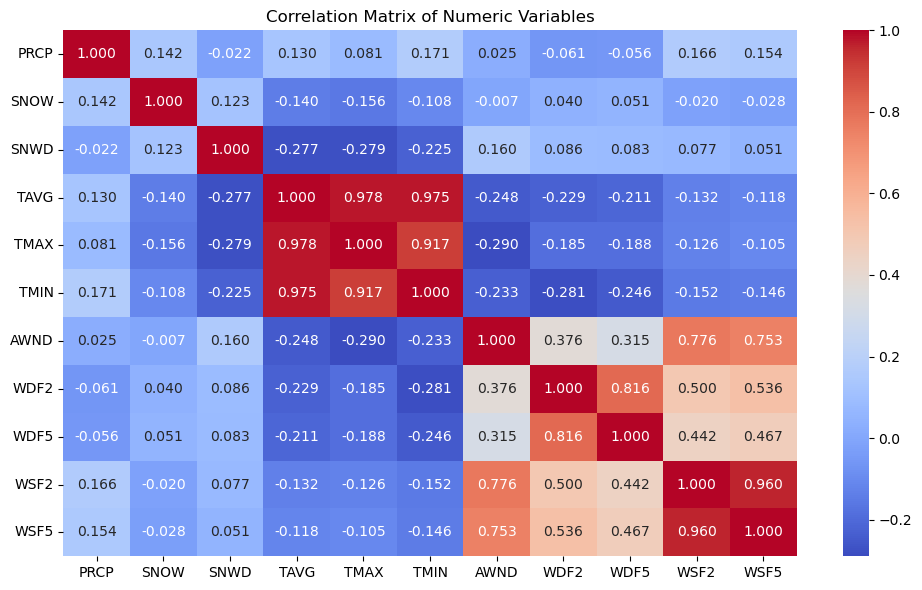

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# F4. Correlation matrix heatmap
numeric_cols = df.select_dtypes(include = "number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(corr, annot = True, fmt = ".3f", cmap = "coolwarm", ax = ax)
ax.set_title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

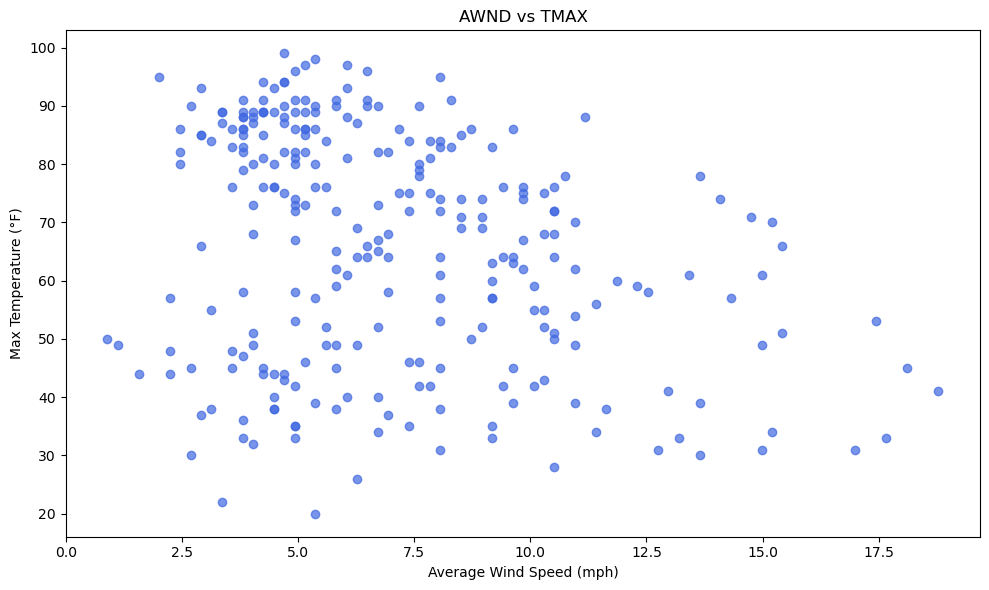

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# F5. Scatterplot of AWND vs TMAX
fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(df["AWND"], df["TMAX"], color = "royalblue", alpha = 0.7)
ax.set_title("AWND vs TMAX")
ax.set_xlabel("Average Wind Speed (mph)")
ax.set_ylabel("Max Temperature (°F)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")

# Q10. Summary statistics for engineered features
df["temp_range"] = df["TMAX"] - df["TMIN"]
df["rain_day"] = (df["PRCP"] > 0).astype(int)
df["wind_gust_ratio"] = df["WSF5"] / df["AWND"]

for col in ["temp_range", "rain_day", "wind_gust_ratio"]:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.3f}")
    print(f"  SD: {df[col].std():.3f}")
    print(f"  Min: {df[col].min():.3f}")
    print(f"  Max: {df[col].max():.3f}")


temp_range:
  Mean: 19.262
  SD: 7.240
  Min: 4.000
  Max: 40.000

rain_day:
  Mean: 0.335
  SD: 0.473
  Min: 0.000
  Max: 1.000

wind_gust_ratio:
  Mean: 4.277
  SD: 1.748
  Min: 1.934
  Max: 14.184


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import t

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df["month"] = df["DATE"].dt.month

# Q13. Test whether TAVG differs between January and July
jan = df[df["month"] == 1]["TAVG"].dropna()
jul = df[df["month"] == 7]["TAVG"].dropna()

# Observed mean difference
diff = jul.mean() - jan.mean()

# Two-sample t-test
t_stat, p_val = stats.ttest_ind(jul, jan)

# Welch-Satterthwaite degrees of freedom
s1, s2 = jul.std(), jan.std()
m, n = len(jul), len(jan)
df_deg = (s1**2 / m + s2**2 / n)**2 / ((s1**2 / m)**2 / (m - 1) + (s2**2 / n)**2 / (n - 1))

# 95% confidence interval for the observed mean difference
se = np.sqrt(s1**2 / m + s2**2 / n)
t_crit = t.ppf(0.975, df = df_deg)
ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"January mean TAVG: {jan.mean():.3f}")
print(f"July mean TAVG: {jul.mean():.3f}")
print(f"Observed difference in means: {diff:.3f}")
print(f"95% CI: ({ci_low:.3f}, {ci_high:.3f})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

January mean TAVG: 30.645
July mean TAVG: 80.516
Observed difference in means: 49.871
95% CI: (46.815, 52.927)
t-statistic: 33.1026
p-value: 0.0000


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import t

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["rain_day"] = (df["PRCP"] > 0).astype(int)
df["wind_gust_ratio"] = df["WSF5"] / df["AWND"]

# Q14. Test whether the average wind_gust_ratio differs on rain days vs non-rain days
rain = df[df["rain_day"] == 1]["wind_gust_ratio"].dropna()
no_rain = df[df["rain_day"] == 0]["wind_gust_ratio"].dropna()

# Observed mean difference
diff = rain.mean() - no_rain.mean()

# Two-sample t-test
t_stat, p_val = stats.ttest_ind(rain, no_rain)

# Welch-Satterthwaite degrees of freedom
s1, s2 = rain.std(), no_rain.std()
m, n = len(rain), len(no_rain)
df_deg = (s1**2 / m + s2**2 / n)**2 / ((s1**2 / m)**2 / (m - 1) + (s2**2 / n)**2 / (n - 1))

# 95% confidence interval for the observed mean difference
se = np.sqrt(s1**2 / m + s2**2 / n)
t_crit = t.ppf(0.975, df = df_deg)
ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"Rain day mean wind_gust_ratio: {rain.mean():.3f}")
print(f"Non-rain day mean wind_gust_ratio: {no_rain.mean():.3f}")
print(f"Observed difference in means: {diff:.3f}")
print(f"95% CI: ({ci_low:.3f}, {ci_high:.3f})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Rain day mean wind_gust_ratio: 4.651
Non-rain day mean wind_gust_ratio: 4.097
Observed difference in means: 0.554
95% CI: (0.029, 1.080)
t-statistic: 2.4674
p-value: 0.0142


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["temp_range"] = df["TMAX"] - df["TMIN"]
df_clean = df[["temp_range", "AWND"]].dropna()

# Q15. Correlation between temp_range and AWND
r, _ = pearsonr(df_clean["temp_range"], df_clean["AWND"])

# 95% CI using Fisher's z-transformation
n = len(df_clean)
z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)
ci_low = np.tanh(z - 1.96 * se)
ci_high = np.tanh(z + 1.96 * se)

print(f"Correlation: {r:.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")

Correlation: -0.1898
95% CI: (-0.3021, -0.0723)


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["rain_day"] = (df["PRCP"] > 0).astype(int)
df["wind_gust_ratio"] = df["WSF5"] / df["AWND"]

# Drop the rows with missing values in the relevant features
features = ["TMIN", "AWND", "rain_day", "wind_gust_ratio"]
target = "TMAX"

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Normalize the features after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Q16. Fit the linear regression model and predict
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Q17. My Metrics
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Coefficients:
  TMIN: 18.8641
  AWND: -0.6095
  rain_day: -2.6579
  wind_gust_ratio: 1.8470

Intercept: 65.6667
RMSE: 6.5473
MAE: 5.2021
R²: 0.8838


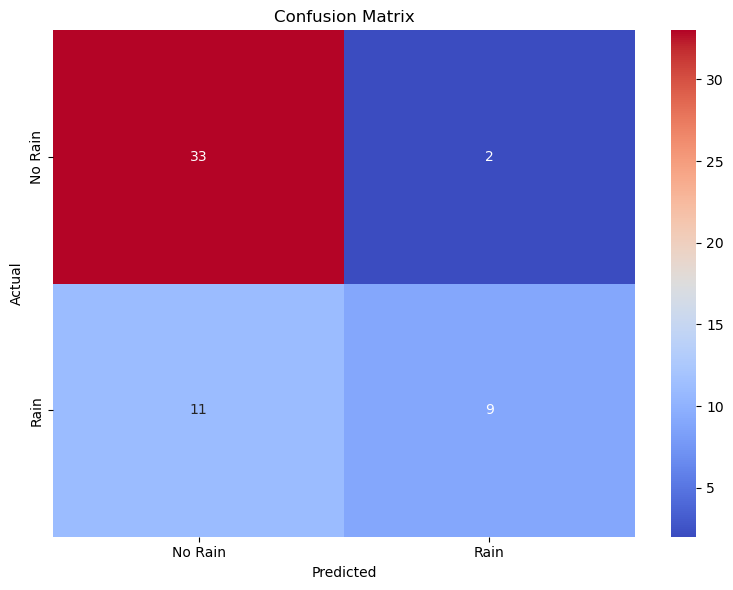


Accuracy: 0.7636
AUC: 0.7557

Coefficients:
  TAVG: 0.3785
  temp_range: -1.1288
  AWND: -0.0332
  wind_gust_ratio: 0.4381

Intercept: -0.9888


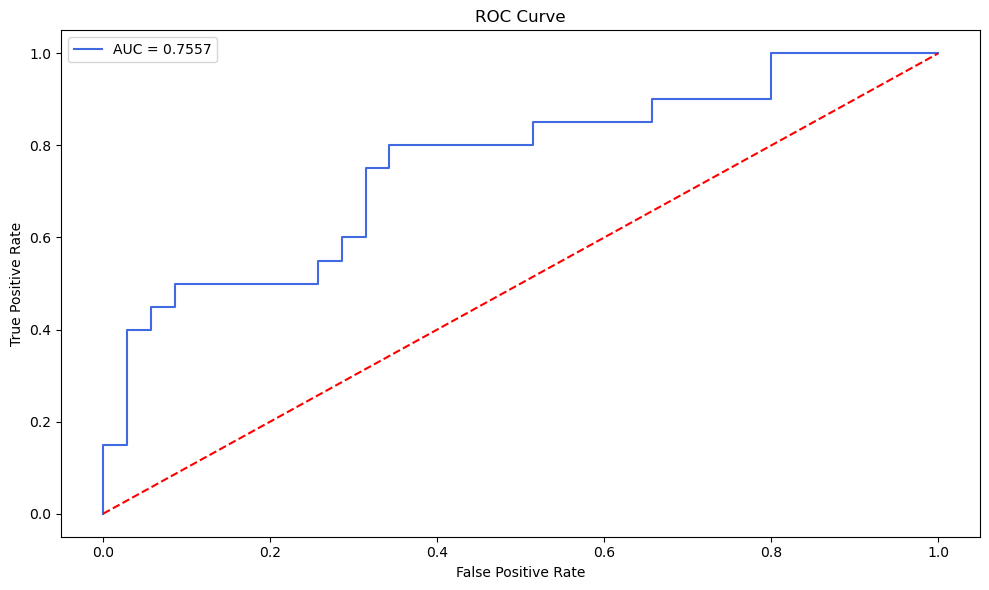

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["temp_range"] = df["TMAX"] - df["TMIN"]
df["rain_day"] = (df["PRCP"] > 0).astype(int)
df["wind_gust_ratio"] = df["WSF5"] / df["AWND"]

# Drop the rows with missing values in the relevant features
features = ["TAVG", "temp_range", "AWND", "wind_gust_ratio"]
target = "rain_day"

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Normalize the features after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Q19. Fit the logistic regression model and predict
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Q20. My Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "coolwarm", 
            xticklabels = ["No Rain", "Rain"], 
            yticklabels = ["No Rain", "Rain"], ax = ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")

print("\nCoefficients:")
for feat, coef in zip(features, model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

print(f"\nIntercept: {model.intercept_[0]:.4f}")

# Plot the ROC curve
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(fpr, tpr, color = "royalblue", label = f"AUC = {auc:.4f}")
ax.plot([0, 1], [0, 1], color = "red", linestyle = "--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Q22. Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Check if the series is regularly spaced hourly
time_diffs = rain["datetime"].diff().dropna()

print("Unique time differences:")
print(time_diffs.value_counts().head(10))

missing_hours = int((rain["datetime"].max() - rain["datetime"].min()).total_seconds() / 3600) + 1 - len(rain)
print(f"Missing hours: {missing_hours}")

Unique time differences:
datetime
0 days 01:00:00    2073
0 days 02:00:00     130
0 days 03:00:00      77
0 days 04:00:00      35
0 days 05:00:00      32
0 days 07:00:00      19
0 days 09:00:00      18
0 days 06:00:00      16
0 days 15:00:00      13
0 days 08:00:00      12
Name: count, dtype: int64
Missing hours: 23509


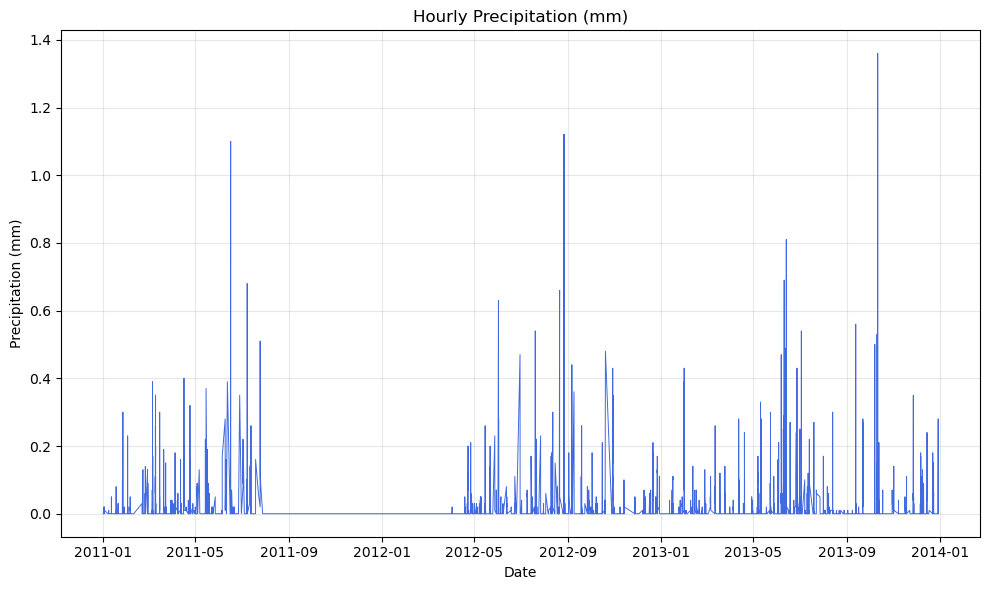

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Drop the rows where precip_mm is 999.99
rain = rain[rain["precip_mm"] < 999]

# F6. Plot the raw hourly precip_mm time series
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(rain["datetime"], rain["precip_mm"], color = "royalblue", linewidth = 0.7)
ax.set_title("Hourly Precipitation (mm)")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm)")
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

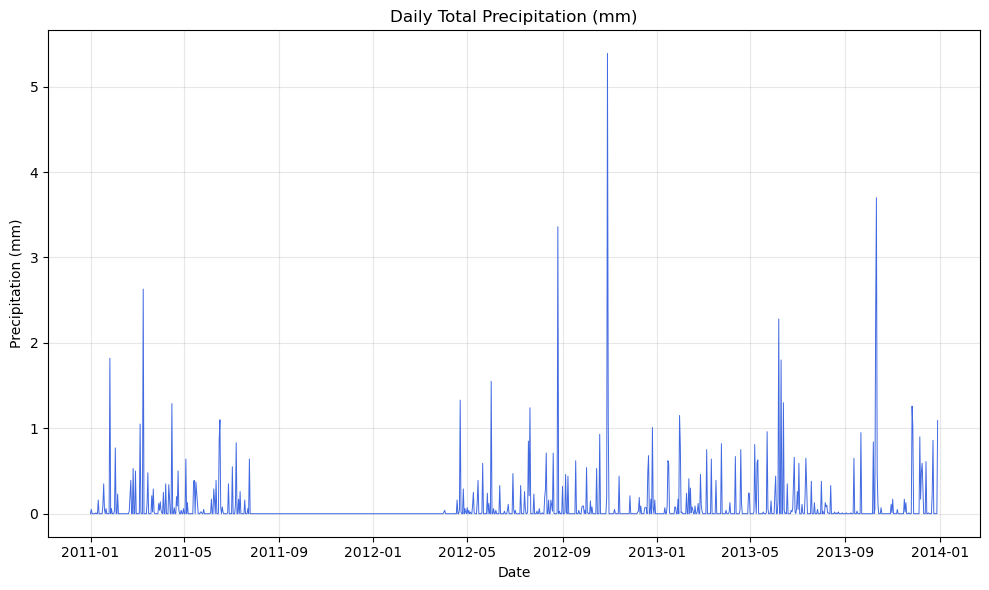

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Drop the rows where precip_mm is 999.99
rain = rain[rain["precip_mm"] < 999]

# F7. Aggregate to daily total precipitation and plot
rain_daily = rain.resample("D", on = "datetime")["precip_mm"].sum()

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(rain_daily.index, rain_daily.values, color = "royalblue", linewidth = 0.7)
ax.set_title("Daily Total Precipitation (mm)")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm)")
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

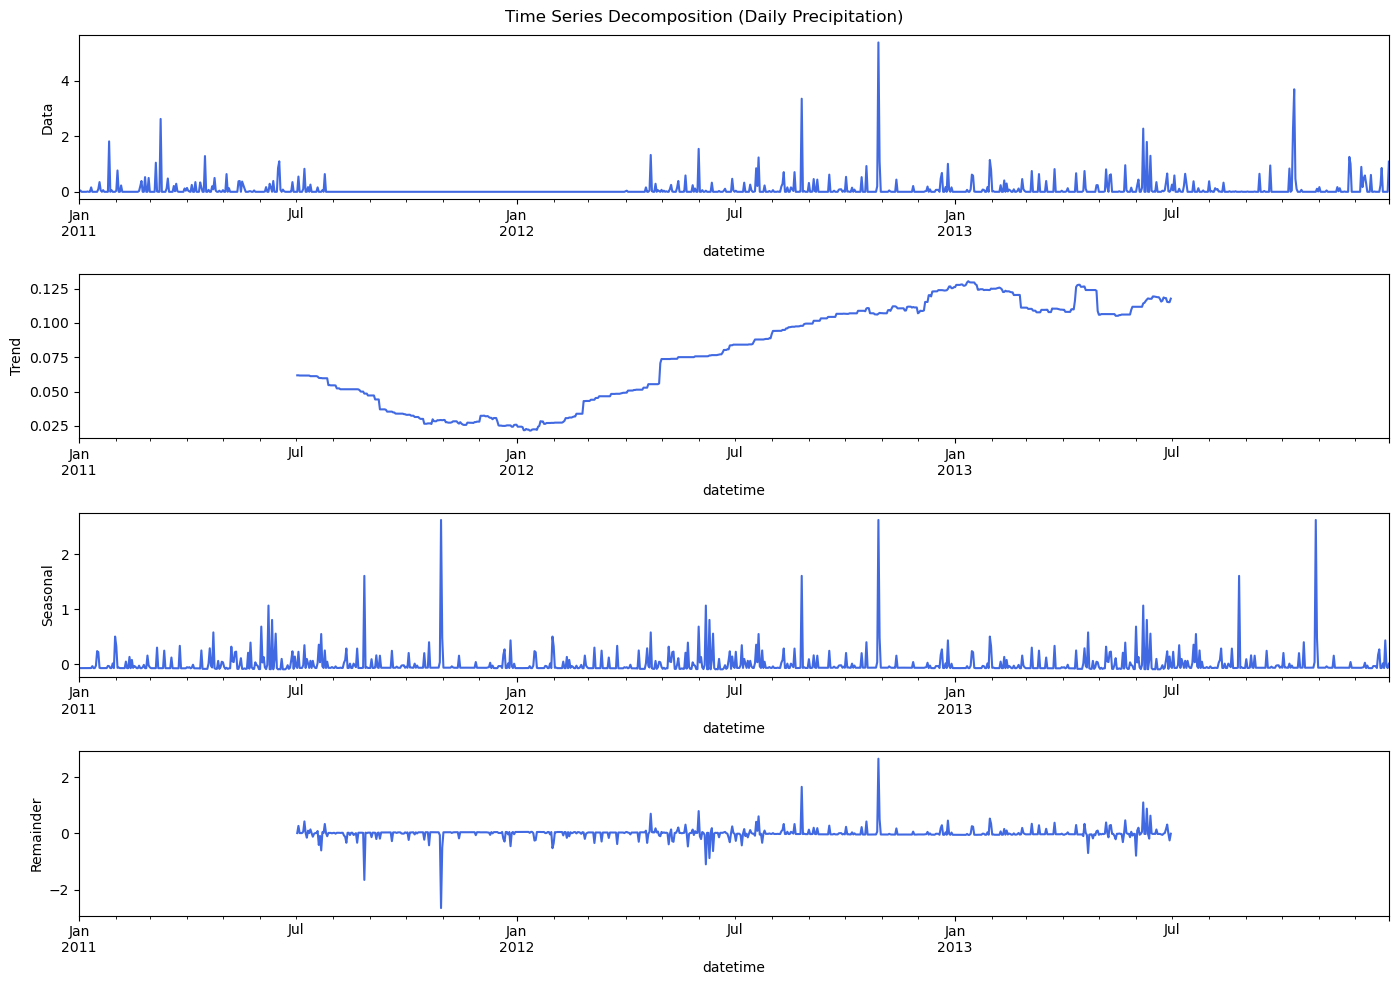

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Drop the rows where precip_mm is 999.99
rain = rain[rain["precip_mm"] < 999]

# Aggregate to daily total precipitation
rain_daily = rain.resample("D", on = "datetime")["precip_mm"].sum()

# Q25. Time decomposition on the daily series
decomp = seasonal_decompose(rain_daily, model = "additive", period = 365)

fig, axes = plt.subplots(4, 1, figsize = (14, 10))
decomp.observed.plot(ax = axes[0], color = "royalblue")
axes[0].set_ylabel("Data")
decomp.trend.plot(ax = axes[1], color = "royalblue")
axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax = axes[2], color = "royalblue")
axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax = axes[3], color = "royalblue")
axes[3].set_ylabel("Remainder")
plt.suptitle("Time Series Decomposition (Daily Precipitation)")
plt.tight_layout()
plt.show()

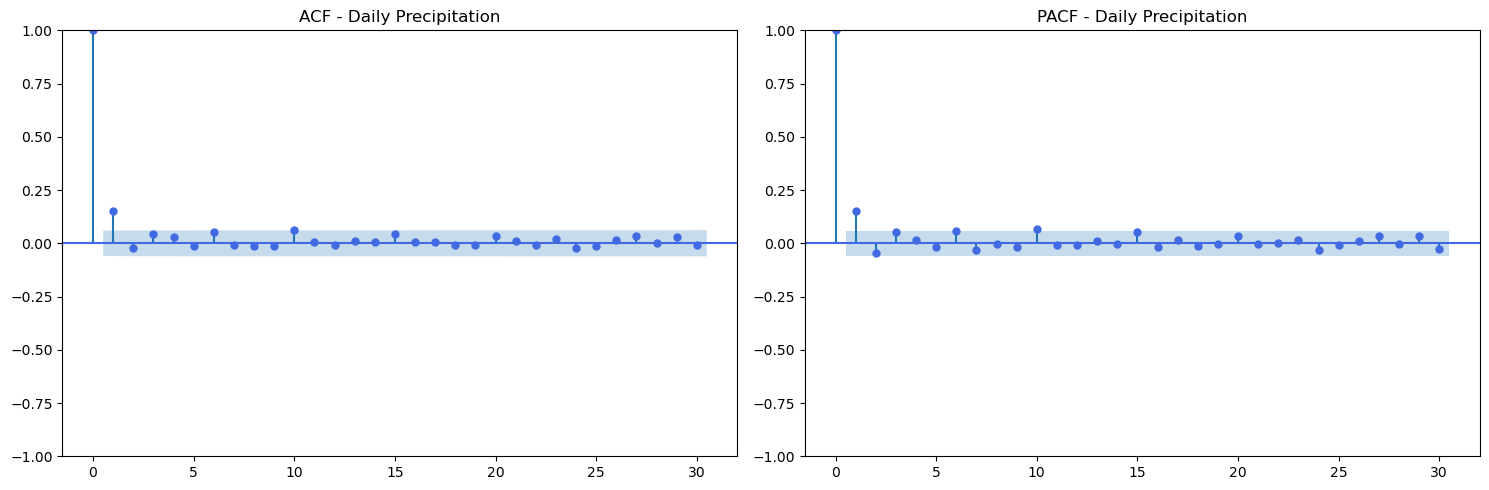

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Drop the rows where precip_mm is 999.99
rain = rain[rain["precip_mm"] < 999]

# Aggregate to daily total precipitation
rain_daily = rain.resample("D", on = "datetime")["precip_mm"].sum()

# Q26. ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
plot_acf(rain_daily, lags = 30, ax = axes[0], color = "royalblue")
axes[0].set_title("ACF - Daily Precipitation")
plot_pacf(rain_daily, lags = 30, ax = axes[1], color = "royalblue")
axes[1].set_title("PACF - Daily Precipitation")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

# Load the hourly precipitation dataset
rain = pd.read_csv("data/rain_hourly_clean.csv")

# Parse datetime and sort
rain["datetime"] = pd.to_datetime(rain["datetime"])
rain = rain.sort_values("datetime").reset_index(drop = True)

# Drop the rows where precip_mm is 999.99
rain = rain[rain["precip_mm"] < 999]

# Aggregate to daily total precipitation
rain_daily = rain.resample("D", on = "datetime")["precip_mm"].sum()

# Q27. Log-transform and fit the AR(p) model
rain_daily_log = np.log1p(rain_daily)

# Use AIC to select p
aic_scores = {}
for p in range(1, 11):
    model = AutoReg(rain_daily_log, lags = p).fit()
    aic_scores[p] = model.aic

best_p = min(aic_scores, key = aic_scores.get)
print("AIC scores:")
for p, aic in aic_scores.items():
    print(f"  AR({p}): {aic:.4f}")
print(f"\nBest p: {best_p}")

# Fit the best model
best_model = AutoReg(rain_daily_log, lags = best_p).fit()
print(f"\nAR({best_p}) Coefficients:")
print(best_model.params)

AIC scores:
  AR(1): -665.2815
  AR(2): -663.9077
  AR(3): -665.0402
  AR(4): -661.8668
  AR(5): -658.4101
  AR(6): -661.9005
  AR(7): -658.9674
  AR(8): -655.4722
  AR(9): -652.2404
  AR(10): -655.4406

Best p: 1

AR(1) Coefficients:
const           0.052958
precip_mm.L1    0.153123
dtype: float64


C:\Users\momoh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\momoh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\momoh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\momoh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

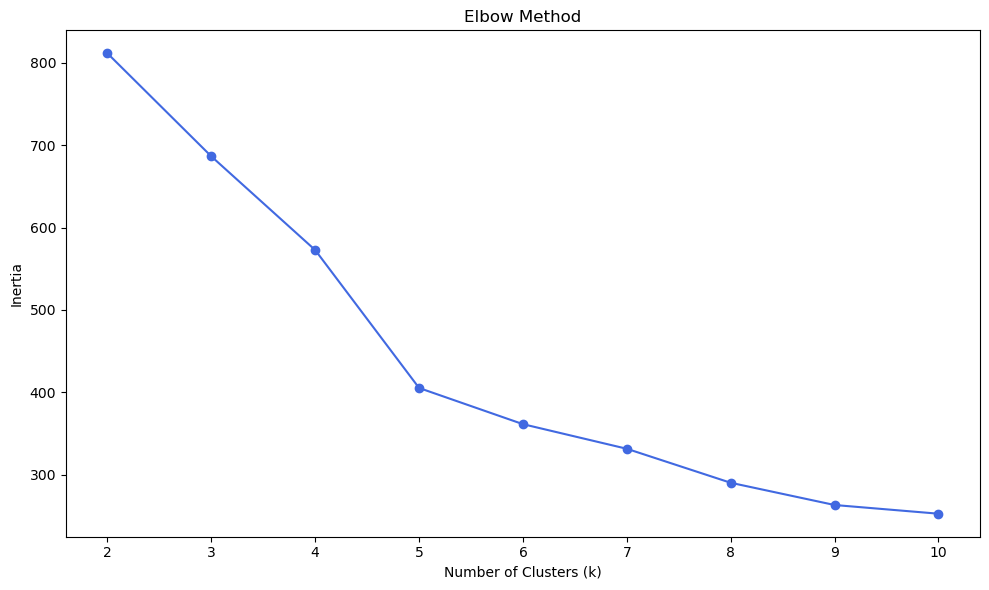

C:\Users\momoh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


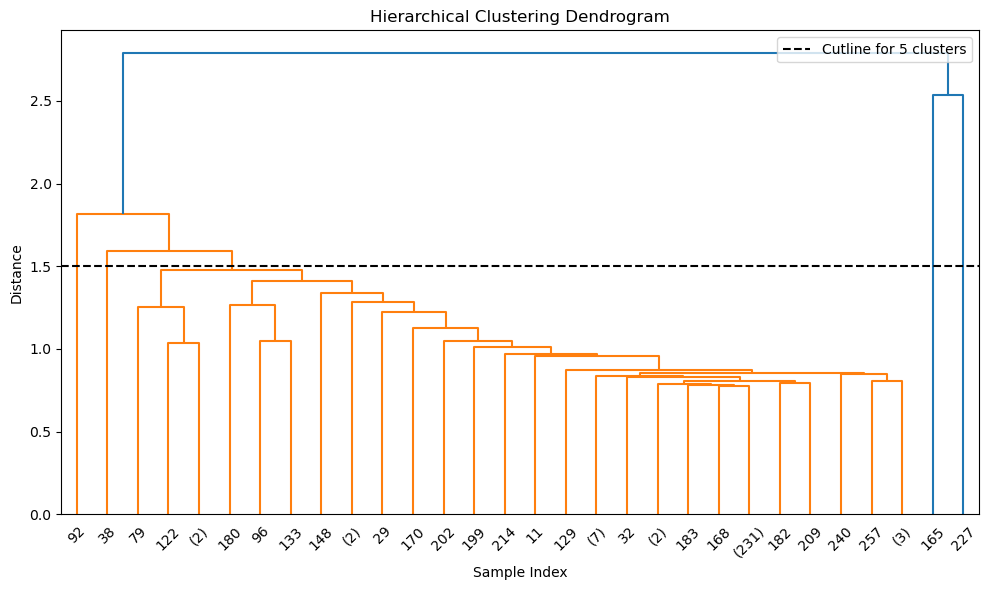

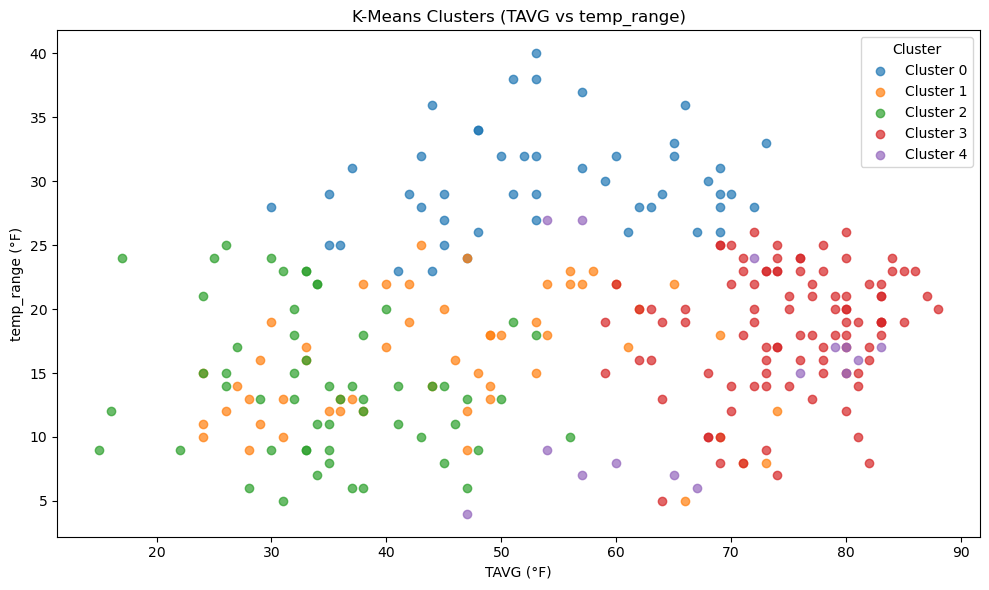

               TAVG  PRCP   AWND  temp_range
kmeans_label                                
0             53.83  0.02   5.90       29.94
1             45.55  0.03  12.11       15.85
2             34.91  0.09   5.30       14.05
3             75.07  0.06   5.61       18.38
4             67.47  1.09   7.81       14.40


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the daily weather dataset
df = pd.read_csv("data/clean_daily_weather.csv")
df["temp_range"] = df["TMAX"] - df["TMIN"]

# Feature selection and scaling
features = ["TAVG", "PRCP", "AWND", "temp_range"]
df_cluster = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Elbow method to choose k
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(range(2, 11), inertias, color = "royalblue", marker = "o")
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

# Q29. Fit k-means with reasonable k-choice (k = 5)
km = KMeans(n_clusters = 5, random_state = 42)
df_cluster["kmeans_label"] = km.fit_predict(X_scaled)

# Fit hierarchical clustering
linked = linkage(X_scaled)

# F8. Dendrogram and scatter plot
fig, ax = plt.subplots(figsize = (10, 6))

# Dendrogram
dendrogram(linked, ax = ax, truncate_mode = "lastp", p = 30)
ax.axhline(y = 1.5, color = "k", linestyle = "--", label = "Cutline for 5 clusters")
ax.legend()
ax.set_title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

# Scatter Plot
fig, ax = plt.subplots(figsize = (10, 6))
for cluster in sorted(df_cluster["kmeans_label"].unique()):
    mask = df_cluster["kmeans_label"] == cluster
    ax.scatter(df_cluster.loc[mask, "TAVG"], df_cluster.loc[mask, "temp_range"],
               alpha = 0.7, label = f"Cluster {cluster}")
ax.set_title("K-Means Clusters (TAVG vs temp_range)")
ax.set_xlabel("TAVG (°F)")
ax.set_ylabel("temp_range (°F)")
ax.legend(title = "Cluster")
plt.tight_layout()
plt.show()

print(df_cluster.groupby("kmeans_label")[features].mean().round(2))